## Classification Model for Loan Denial or Approval
### Credits to Karina Data Scientist (YouTube)
This project applies machine learning (Logistic Regression) to predict loan approval status (Approved or Denied) based on applicant profiles.

Dataset is taken from Kaggle: https://www.kaggle.com/datasets/sujithmandala/simple-loan-classification-dataset

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

df = pd.read_csv('loan.csv')

### Step 1: Data Exploration and Pre-Processing
Before training the ML model, it is important to explore the features and perform data cleaning since handling missing values and ensuring data consistency directly impacts algorithm performance.

Below, the dataset structure is inspected and scanned for missing values.

In [2]:
df.head()

,age,gender,occupation,education_level,marital_status,income,credit_score,loan_status
0,32,Male,Engineer,Bachelor's,Married,85000,720,Approved
1,45,Female,Teacher,Master's,Single,62000,680,Approved
2,28,Male,Student,High School,Single,25000,590,Denied
3,51,Female,Manager,Bachelor's,Married,105000,780,Approved
4,36,Male,Accountant,Bachelor's,Married,75000,710,Approved


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61 entries, 0 to 60
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   age              61 non-null     int64 
 1   gender           61 non-null     object
 2   occupation       61 non-null     object
 3   education_level  61 non-null     object
 4   marital_status   61 non-null     object
 5   income           61 non-null     int64 
 6   credit_score     61 non-null     int64 
 7   loan_status      61 non-null     object
dtypes: int64(3), object(5)
memory usage: 3.9+ KB


In [4]:
df.isnull().sum()

age                0
gender             0
occupation         0
education_level    0
marital_status     0
income             0
credit_score       0
loan_status        0
dtype: int64

### Step 2: Encoding the Data
Most ML algorithms, specifically this one (Logistic Regression), cannot work with categorical values and require numeric input.

The following step applies One-Hot Encoding to the categorical features. The drop_first=True parameter is used to prevent multicollinearity.

In [5]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,age,income,credit_score,gender_Male,occupation_Analyst,occupation_Architect,occupation_Artist,occupation_Banker,occupation_Chef,occupation_Consultant,...,occupation_Stylist,occupation_Teacher,occupation_Veterinarian,occupation_Writer,education_level_Bachelor's,education_level_Doctoral,education_level_High School,education_level_Master's,marital_status_Single,loan_status_Denied
0,32,85000,720,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
1,45,62000,680,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,True,True,False
2,28,25000,590,True,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,True,True
3,51,105000,780,False,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False
4,36,75000,710,True,False,False,False,False,False,False,...,False,False,False,False,True,False,False,False,False,False


### Step 3: Separating the Data Set
Prior to model training, the dataset must be partitioned into independent and dependent variables. Following feature isolation, the data is split into training and testing subsets. This separation helps the ML model learn the relationship between features and the target variable.

In the implementation below, features & the target variable are defined and a standard 80/20 train-test split is applied.

In [6]:
X = df_encoded.drop(columns=['loan_status_Denied'])
Y = df_encoded['loan_status_Denied']

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

In [8]:
model = LogisticRegression()

### Step 4: Training the Model
In the implemenation below, the model is then trained on the variables and the results are printed.

In [9]:
model.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [10]:
Y_pred = model.predict(X_test)

In [11]:
accuracy = accuracy_score(Y_test, Y_pred)
print(accuracy)

1.0


In [12]:
confusion = confusion_matrix(Y_test, Y_pred)
print(confusion)

[[9 0]
 [0 4]]


In [13]:
report = classification_report(Y_test, Y_pred)
print(report)

              precision    recall  f1-score   support

       False       1.00      1.00      1.00         9
        True       1.00      1.00      1.00         4

    accuracy                           1.00        13
   macro avg       1.00      1.00      1.00        13
weighted avg       1.00      1.00      1.00        13



### Step 5: Making Predictions
The implementation below creates a new data frame matching the feature schema used during training. The predicition model is run and outputs the results below.

In [14]:
import numpy as np

new_df = pd.DataFrame(np.zeros((1,X_train.shape[1])), columns=X_train.columns)

new_df.loc[0, [
    'age', 
    'income', 
    'credit_score', 
    'gender_Male', 
    'occupation_Engineer', 
    'education_level_Bachelor\'s',
    'marital_status_Single'
]] = [35, 80000, 650, 1, 1, 1, 1]

prediction = model.predict(new_df)

if prediction[0]:
    results = "Denied"
else:
    results = "Approved"

print(results)

Approved


### Step 6: Validating the Model
Since the results of this model was very high, validation will be done.

The implementation below uses cross-validation alongside other validation techniques to evaluate the model's performance.

In [16]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(model, X, Y, cv=5)
print(cv_scores)
print(cv_scores.mean())

[1.         0.91666667 0.91666667 1.         1.        ]
0.9666666666666666


### Check for imbalanced data

In [17]:
df_encoded['loan_status_Denied'].value_counts()

loan_status_Denied
False    45
True     16
Name: count, dtype: int64

### Look for data leakage and feature importance

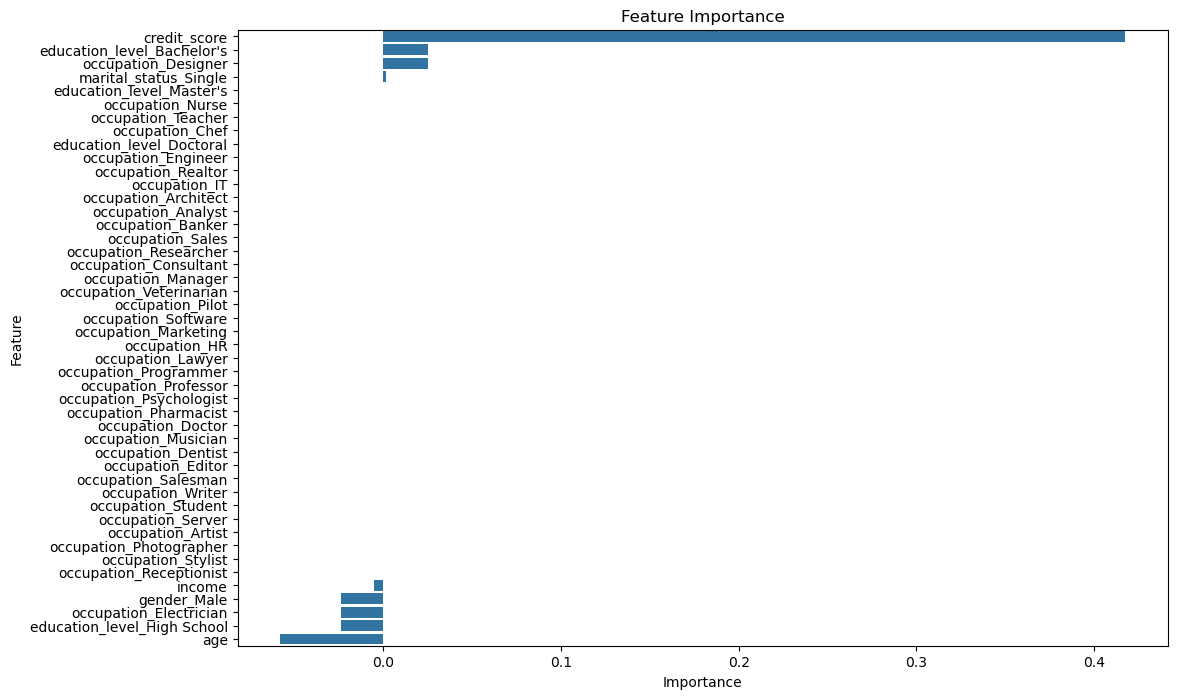

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.coef_[0]})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='Importance', y='Feature', data=feature_importance)
plt.title('Feature Importance')
plt.show()